# Machine Learnin Project

### Loading and visualizing the dataset

(6, 6000)
(6000,)


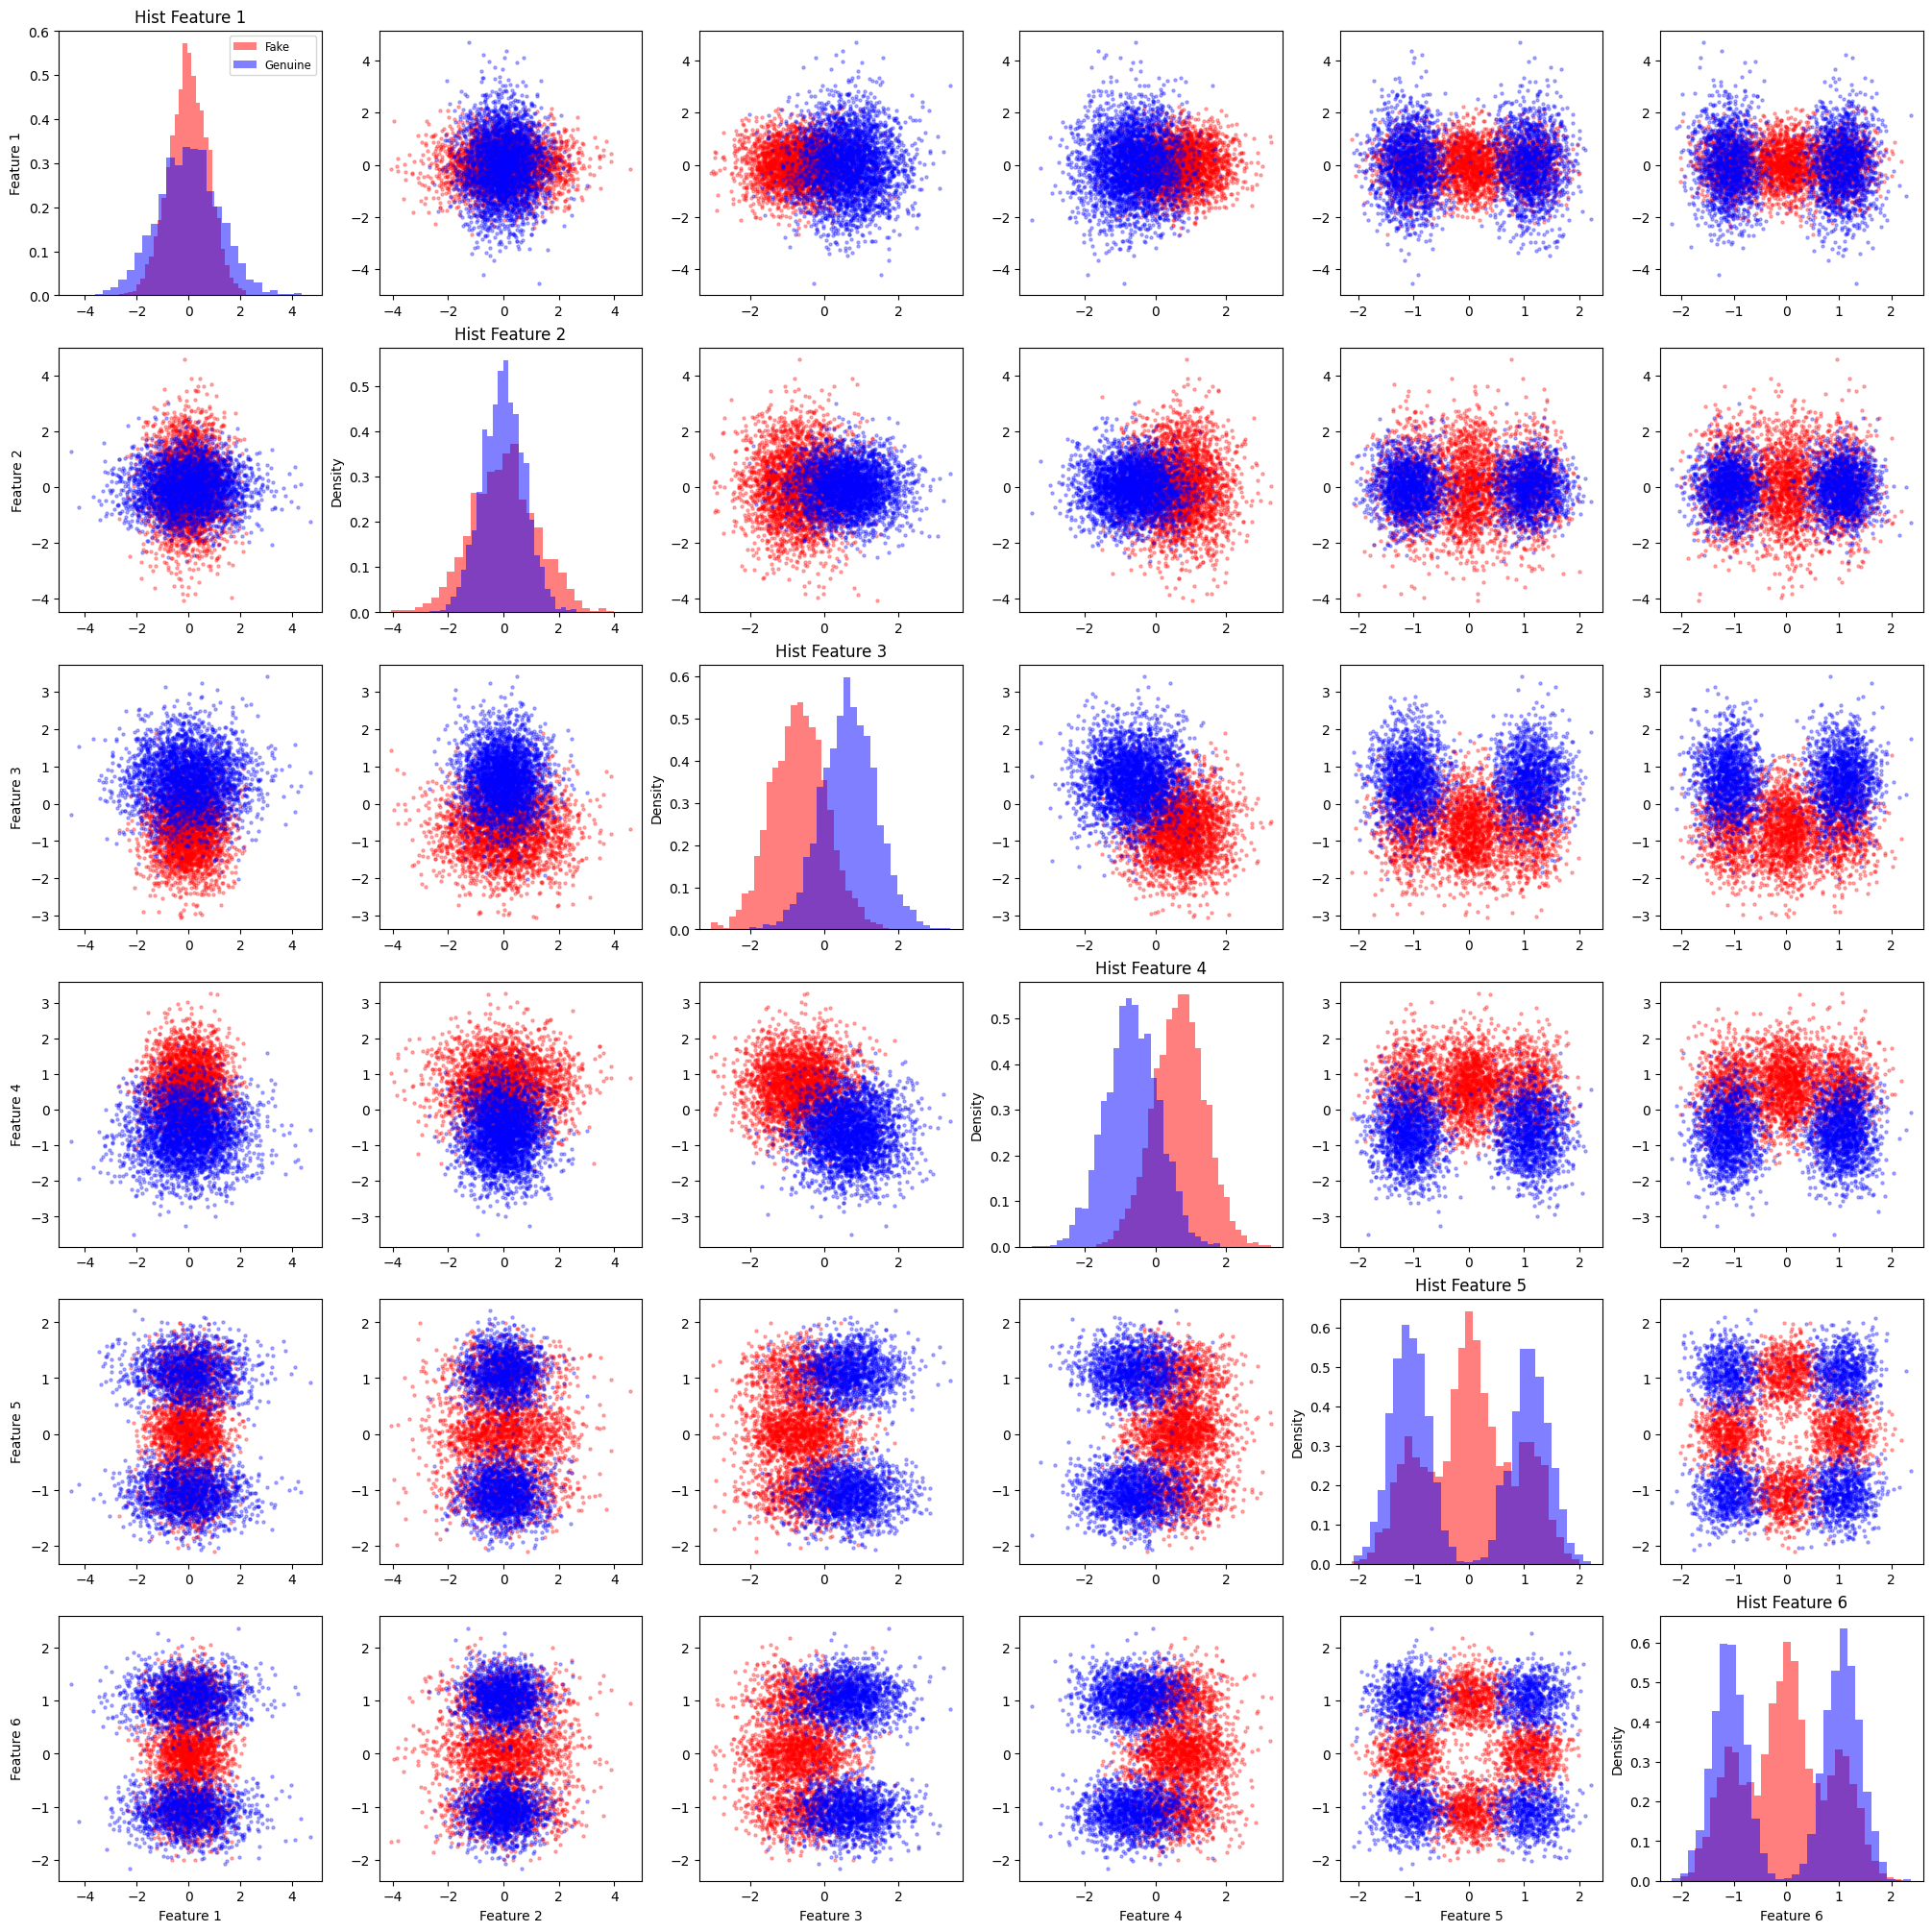

In [7]:
from utils import *
from dimensionality_reduction import *

D, L = load("train_data.txt")
print(D.shape)
print(L.shape)

plot_features(D,L)

### Effects of PCA projection across all dimensions

Only the first dimension, associated to the highest eigenvalue, seems to be relevant in this analysys.

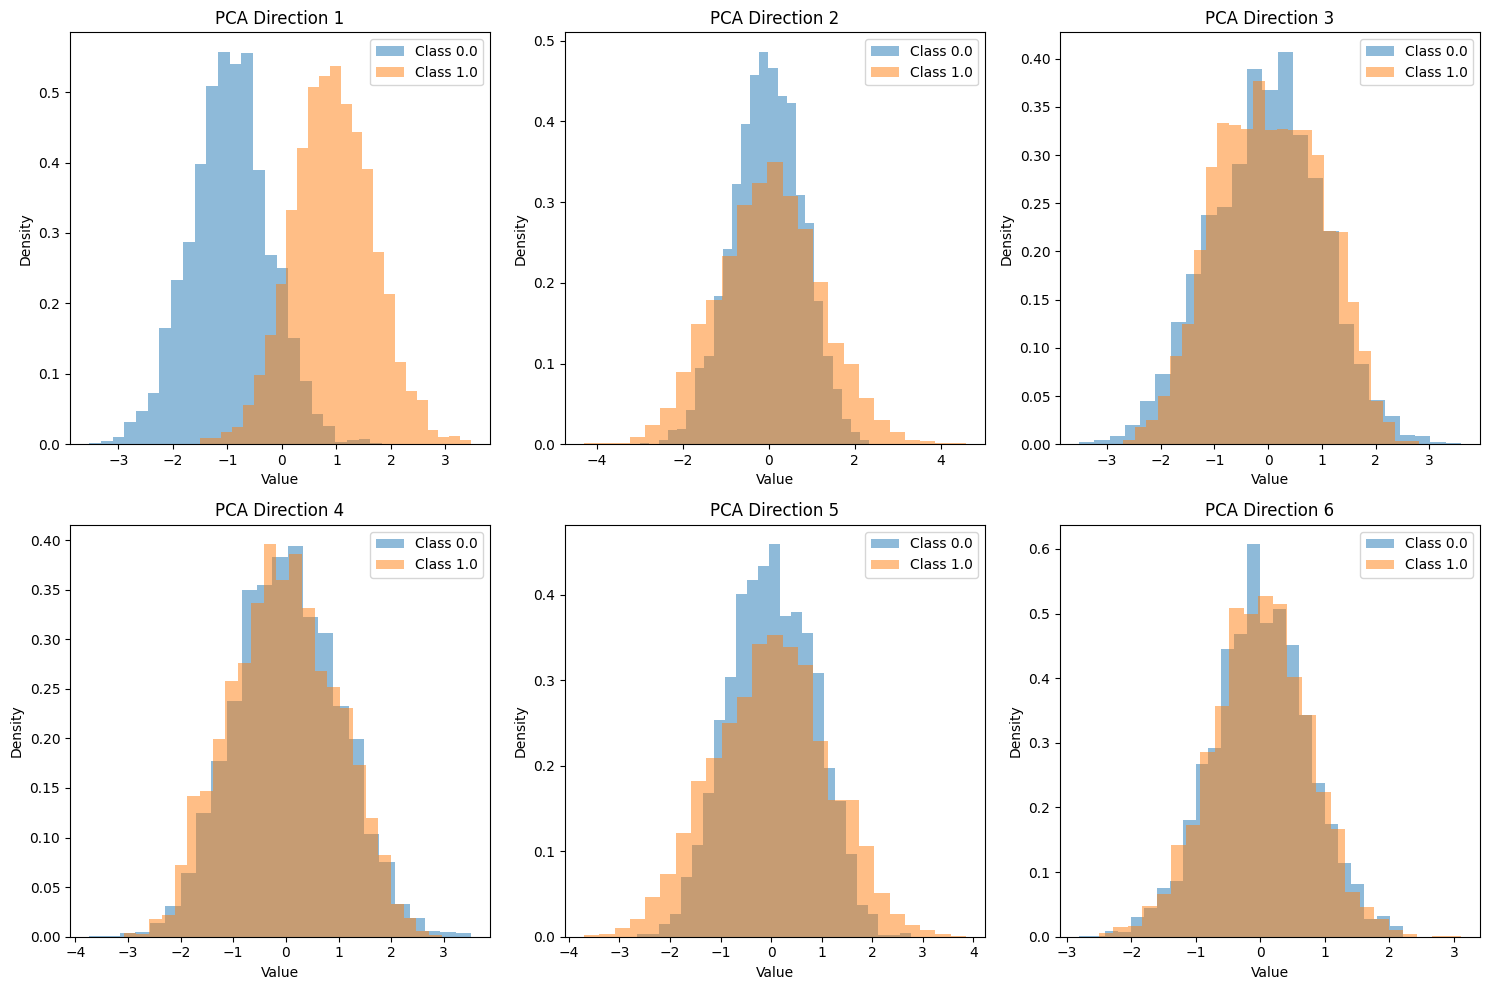

In [8]:
U = PCA(D, 6)
D_pca = U.T@D # New space with same dimensions as D
plot_histograms(D_pca, L)

### Applying LDA only

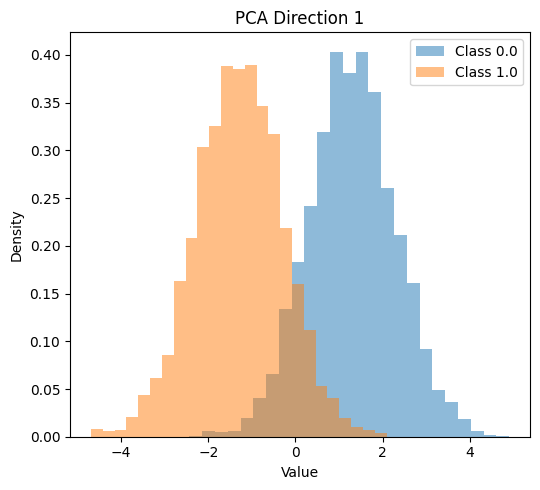

In [9]:
U = LDA(D, L, 1)
D_lda = U.T@D
plot_histograms(D_lda, L)

### Use of LDA for classification
A simple mean-based classifier will be used to evaluate the performance

In [13]:
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L) # Dataset split
U_lda = LDA(D_training, L_training, 1)

D_training_lda = U_lda.T @ D_training # dim: [1 x N_training]
D_eval_lda = U_lda.T @ D_eval         # dim: [1 x N_eval]

m0 = D_training_lda[0, L_training == 0].mean()
m1 = D_training_lda[0, L_training == 1].mean()

threshold = (m0 + m1) / 2.0

predicted = np.zeros(L_eval.shape)

predicted[D_eval_lda[0, :] > threshold] = 1
predicted[D_eval_lda[0, :] <= threshold] = 0


correct = np.sum(predicted == L_eval)
wrong = L_eval.shape[0] - correct
print("Correct: " + str(correct))
print("Wrong: " + str(wrong))
print("Accuracy: " + str(correct/L_eval.shape[0]))
print("Error rate: " + str(wrong/L_eval.shape[0]))

Correct: 1814
Wrong: 186
Accuracy: 0.907
Error rate: 0.093


### Full dimensionality reduction preprocessing pipeline: PCA + LDA
A simple mean-based classifier will be used to evaluate the performance while decreasing PCA dimensions.

In [ ]:
(D_training, L_training), (D_eval, L_eval) = split_db_2to1(D, L) # Dataset split

for i in range(6, 0, -1):
    U_pca = PCA(D_training, i)

    D_training_pca = U_pca.T @ D_training 
    D_eval_pca = U_pca.T @ D_eval

    U_lda = LDA(D_training_pca, L_training, 1)

    D_training_lda = U_lda.T @ D_training_pca 
    D_eval_lda = U_lda.T @ D_eval_pca         

    m0 = D_training_lda[0, L_training == 0].mean()
    m1 = D_training_lda[0, L_training == 1].mean()

    threshold = (m0 + m1) / 2.0

    predicted = np.zeros(L_eval.shape)

    if m1 > m0:
        predicted[D_eval_lda[0, :] > threshold] = 1
        predicted[D_eval_lda[0, :] <= threshold] = 0
    else:
        predicted[D_eval_lda[0, :] <= threshold] = 1
        predicted[D_eval_lda[0, :] > threshold] = 0

    correct = np.sum(predicted == L_eval)
    wrong = L_eval.shape[0] - correct
    print(f"{i}-dimensions after PCA")
    print("Correct: " + str(correct))
    print("Wrong: " + str(wrong))
    print("Accuracy: " + str(correct/L_eval.shape[0]))
    print("Error rate: " + str(wrong/L_eval.shape[0]))
    print("--------------")

5-dimensions after PCA
Correct: 1814
Wrong: 186
Accuracy: 0.907
Error rate: 0.093
--------------
4-dimensions after PCA
Correct: 1815
Wrong: 185
Accuracy: 0.9075
Error rate: 0.0925
--------------
3-dimensions after PCA
Correct: 1815
Wrong: 185
Accuracy: 0.9075
Error rate: 0.0925
--------------
2-dimensions after PCA
Correct: 1815
Wrong: 185
Accuracy: 0.9075
Error rate: 0.0925
--------------
1-dimensions after PCA
Correct: 1813
Wrong: 187
Accuracy: 0.9065
Error rate: 0.0935
--------------


## Data fits Gaussian model?

In [ ]:
classes = [0, 1, 2]
n_features = D.shape[0]

for i in range(n_features):
    plt.figure()
    plt.title(f"Feature {i}")

    for cls in classes:
        # 1. Isola la feature i-esima per la classe corrente
        row_data = D[i, L == cls] 
        
        # 2. Calcola i parametri ML (Media e Varianza)
        mu_ml = np.mean(row_data)
        var_ml = np.var(row_data)
        # La tua logpdf_GAU_ND si aspetta C come matrice
        C_ml = np.array([[var_ml]]) 
        
        # 3. Crea i punti per il plot della Gaussiana
        x_axis = np.linspace(row_data.min(), row_data.max(), 100)
        # x_axis deve essere (1, 100) per la tua funzione
        res_log_pdf = logpdf_GAU_ND(x_axis.reshape(1, -1), np.array([mu_ml]), C_ml)
        y_axis = np.exp(res_log_pdf)
        
        # 4. Plot dell'istogramma e della PDF
        plt.hist(row_data, bins=20, density=True, alpha=0.4, label=f"Class {cls} Hist")
        plt.plot(x_axis, y_axis, label=f"Class {cls} PDF")
    
    plt.xlabel(f"Valore Feature {i}")
    plt.ylabel("Densità")
    plt.legend()
    plt.show()